
# Índice de Riesgo Climático para Café

Este notebook construye un índice climático de riesgo por clúster a partir de:

- `features_intra_anuales_2007-2024_clusters.csv`
- variables intra-anuales seleccionadas previamente
- modelo Ridge por clúster
- coeficientes calibrados por régimen climático

El objetivo es obtener un índice operativo para evaluar riesgo asociado al rendimiento.


## 1. Librerías

In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error


## 2. Rutas y carga de datos

In [2]:

PROJECT_ROOT = Path().resolve().parents[1]
path = PROJECT_ROOT / "data" / "processed"

archivo = path / "features_intra_anuales_2007-2024_clusters.csv"

df_model = pd.read_csv(archivo)

df_model.head()


,municipio,date,anio,Área sembrada (ha),Rendimiento (t/ha),produccion_t,precip_mm_sum,precip_mm_mean,precip_mm_std,precip_mm_min,...,balance_hidrico_mm_z_mean_anual,balance_hidrico_mm_z_min_anual,balance_hidrico_mm_z_max_anual,deficit_hidrico_mm_z_mean_anual,deficit_hidrico_mm_z_min_anual,deficit_hidrico_mm_z_max_anual,exceso_hidrico_mm_z_mean_anual,exceso_hidrico_mm_z_min_anual,exceso_hidrico_mm_z_max_anual,cluster
0,Aguadas,2007-12-31,2007,4626.0,0.97,4063.0,2660.352575,221.696048,106.472932,39.417551,...,0.343023,-1.319420,1.425035,0.131243,-0.618179,3.480916,0.361895,-1.220112,1.425035,1
1,Anserma,2007-12-31,2007,7125.0,1.30,7131.0,2168.859973,180.738331,79.863766,26.391460,...,0.167279,-1.394092,1.550450,0.116148,-0.664257,3.258719,0.174870,-1.054646,1.550450,2
2,Aranzazu,2007-12-31,2007,2597.0,1.01,2254.0,2106.546668,175.545556,91.258936,35.359744,...,0.170433,-1.729506,1.957977,0.527726,-0.761310,3.874084,0.227237,-1.051529,1.934536,1
3,Belalcázar,2007-12-31,2007,3734.0,1.20,3835.0,2429.582959,202.465247,85.739394,37.993671,...,0.300368,-1.070850,1.321184,0.093395,-0.684778,3.236328,0.293302,-0.995501,1.367424,2
4,Chinchiná,2007-12-31,2007,5632.0,1.63,9203.0,2530.997565,210.916464,83.768437,58.426388,...,0.109842,-1.212987,1.222853,0.264114,-0.529252,3.675252,0.115842,-1.208808,1.262900,2


## 3. Validaciones iniciales

In [3]:

target = "Rendimiento (t/ha)"

cols_base = ["municipio", "anio", "cluster", target]
faltantes_base = [c for c in cols_base if c not in df_model.columns]

if faltantes_base:
    raise ValueError(f"Faltan columnas base necesarias: {faltantes_base}")

print("Columnas base disponibles")
print(df_model[cols_base].head())


Columnas base disponibles
    municipio  anio  cluster  Rendimiento (t/ha)
0     Aguadas  2007        1                0.97
1     Anserma  2007        2                1.30
2    Aranzazu  2007        1                1.01
3  Belalcázar  2007        2                1.20
4   Chinchiná  2007        2                1.63


## 4. Variables finales del índice

In [4]:

vars_cluster = [
    "et_real_mm_std",
    "et_potencial_mm_std",
    "ndvi_mean_m05",
    "exceso_hidrico_mm_m02",
    "temp_max_max_m04_06",
    "balance_hidrico_mm_min_m01_06",
    "ndvi_mean_min_m01_06",
    "precip_max_mm_m07"
]

faltantes_vars = [v for v in vars_cluster if v not in df_model.columns]

if faltantes_vars:
    raise ValueError(f"Faltan variables del índice: {faltantes_vars}")

print("Variables del índice disponibles")


Variables del índice disponibles



## 5. Ajuste del modelo Ridge por clúster

En este bloque se recalculan los coeficientes del modelo por clúster.  
Esto es necesario porque este notebook es independiente y no hereda variables del notebook de selección.


In [5]:

coeficientes = {}
resultados_modelo = []

for c in sorted(df_model["cluster"].dropna().unique()):

    df_c = df_model[df_model["cluster"] == c].copy()

    X_c = df_c[vars_cluster]
    y_c = df_c[target]

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ])

    # Validación cruzada flexible según tamaño del clúster
    n_obs = len(df_c)
    cv = min(5, n_obs)

    if cv >= 3:
        scores = cross_val_score(pipeline, X_c, y_c, cv=cv, scoring="r2")
        r2_cv = scores.mean()
    else:
        r2_cv = np.nan

    # Ajuste final sobre todo el clúster
    pipeline.fit(X_c, y_c)
    y_pred = pipeline.predict(X_c)

    r2_train = r2_score(y_c, y_pred)
    mae_train = mean_absolute_error(y_c, y_pred)

    coef = pd.Series(
        pipeline.named_steps["model"].coef_,
        index=vars_cluster
    ).sort_values(key=abs, ascending=False)

    coeficientes[c] = coef

    resultados_modelo.append({
        "cluster": c,
        "n_obs": n_obs,
        "r2_cv": r2_cv,
        "r2_train": r2_train,
        "mae_train": mae_train
    })

resultados_modelo = pd.DataFrame(resultados_modelo)
resultados_modelo


,cluster,n_obs,r2_cv,r2_train,mae_train
0,0,36,-3.650372,0.086728,0.189669
1,1,162,-0.224740,0.163169,0.206214
2,2,198,-0.267925,0.129850,0.182128
3,3,54,-1.102603,0.416179,0.110268


## 6. Coeficientes por clúster

In [6]:

for c, coef in coeficientes.items():
    print(f"\nCluster {c}")
    print(coef)



Cluster 0
ndvi_mean_m05                   -0.063405
balance_hidrico_mm_min_m01_06   -0.058696
precip_max_mm_m07               -0.046407
ndvi_mean_min_m01_06             0.037433
exceso_hidrico_mm_m02            0.026910
et_potencial_mm_std              0.021235
et_real_mm_std                  -0.015602
temp_max_max_m04_06              0.007087
dtype: float64

Cluster 1
et_potencial_mm_std              0.107411
et_real_mm_std                  -0.066673
temp_max_max_m04_06              0.048003
ndvi_mean_m05                    0.042064
ndvi_mean_min_m01_06             0.028381
balance_hidrico_mm_min_m01_06   -0.019302
exceso_hidrico_mm_m02            0.014097
precip_max_mm_m07               -0.007680
dtype: float64

Cluster 2
temp_max_max_m04_06              0.049114
et_potencial_mm_std              0.046056
precip_max_mm_m07                0.042655
ndvi_mean_m05                    0.038343
et_real_mm_std                  -0.030977
exceso_hidrico_mm_m02           -0.019841
balance_hidri


## 7. Construcción del índice climático calibrado por clúster

El índice se calcula así:

1. Se estandarizan las variables dentro de cada clúster.
2. Se ponderan usando los coeficientes Ridge del clúster.
3. Se suma el aporte ponderado de cada variable.


In [7]:

df_model["indice_cluster_raw"] = np.nan

for c in sorted(df_model["cluster"].dropna().unique()):

    df_c = df_model[df_model["cluster"] == c].copy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_c[vars_cluster])
    X_scaled = pd.DataFrame(
        X_scaled,
        columns=vars_cluster,
        index=df_c.index
    )

    pesos = coeficientes[c].loc[vars_cluster]

    indice = X_scaled.mul(pesos, axis=1).sum(axis=1)

    df_model.loc[df_c.index, "indice_cluster_raw"] = indice

df_model[["municipio", "anio", "cluster", target, "indice_cluster_raw"]].head()


,municipio,anio,cluster,Rendimiento (t/ha),indice_cluster_raw
0,Aguadas,2007,1,0.97,0.065213
1,Anserma,2007,2,1.30,-0.041384
2,Aranzazu,2007,1,1.01,-0.050774
3,Belalcázar,2007,2,1.20,0.084197
4,Chinchiná,2007,2,1.63,0.043257



## 8. Normalización del índice

Se normaliza el índice dentro de cada clúster para que sea comparable en términos relativos.


In [8]:

df_model["indice_cluster"] = np.nan

for c in sorted(df_model["cluster"].dropna().unique()):

    idx = df_model["cluster"] == c
    media = df_model.loc[idx, "indice_cluster_raw"].mean()
    std = df_model.loc[idx, "indice_cluster_raw"].std()

    df_model.loc[idx, "indice_cluster"] = (
        df_model.loc[idx, "indice_cluster_raw"] - media
    ) / std

df_model[["municipio", "anio", "cluster", target, "indice_cluster"]].head()


,municipio,anio,cluster,Rendimiento (t/ha),indice_cluster
0,Aguadas,2007,1,0.97,0.528465
1,Anserma,2007,2,1.30,-0.416760
2,Aranzazu,2007,1,1.01,-0.411458
3,Belalcázar,2007,2,1.20,0.847915
4,Chinchiná,2007,2,1.63,0.435625


## 9. Validación visual del índice

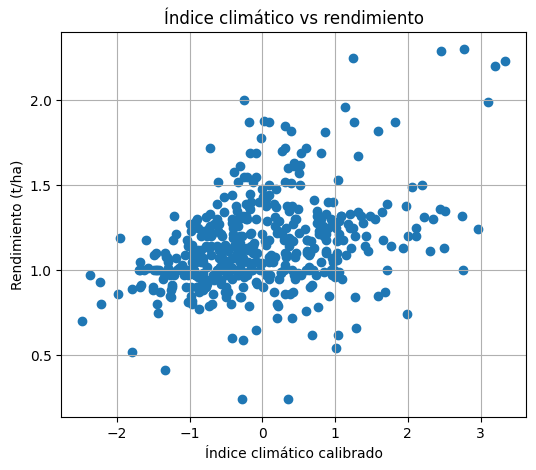

In [9]:

plt.figure(figsize=(6, 5))
plt.scatter(df_model["indice_cluster"], df_model[target])
plt.xlabel("Índice climático calibrado")
plt.ylabel(target)
plt.title("Índice climático vs rendimiento")
plt.grid()
plt.show()


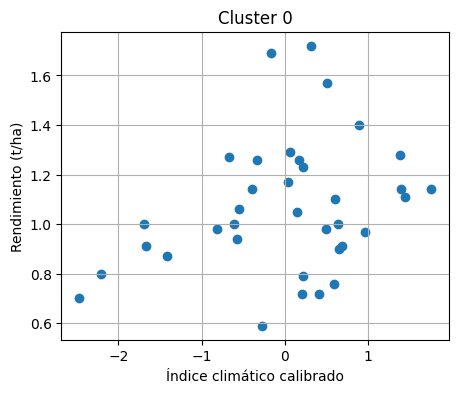

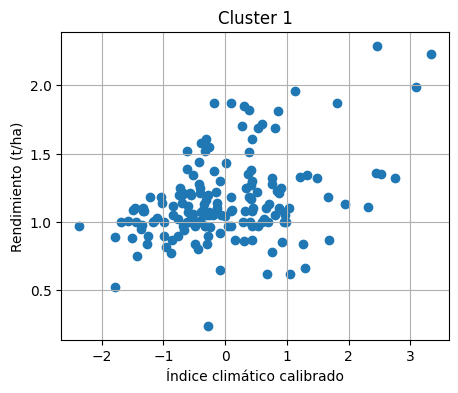

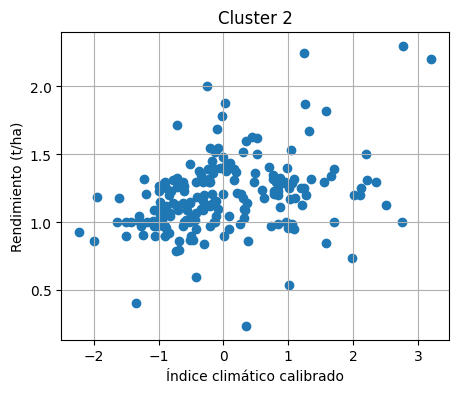

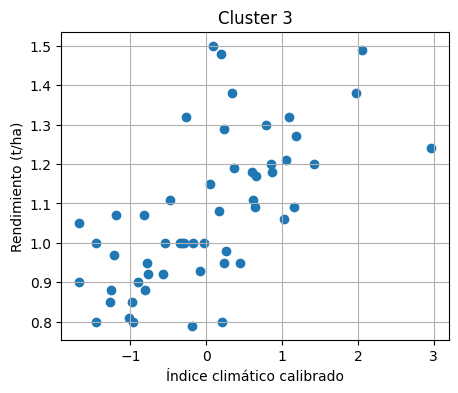

In [10]:

for c in sorted(df_model["cluster"].dropna().unique()):

    df_c = df_model[df_model["cluster"] == c]

    plt.figure(figsize=(5, 4))
    plt.scatter(df_c["indice_cluster"], df_c[target])
    plt.xlabel("Índice climático calibrado")
    plt.ylabel(target)
    plt.title(f"Cluster {c}")
    plt.grid()
    plt.show()



## 10. Definición de evento de pérdida

Se define evento de pérdida como rendimiento por debajo del percentil 30.  
Este umbral puede ajustarse posteriormente según criterios actuariales o comerciales.


In [11]:

p30_global = df_model[target].quantile(0.30)

df_model["evento_perdida_global"] = (
    df_model[target] <= p30_global
).astype(int)

print("P30 global rendimiento:", p30_global)
df_model["evento_perdida_global"].value_counts()


P30 global rendimiento: 1.0


evento_perdida_global
0    298
1    152
Name: count, dtype: int64


## 11. Umbral de riesgo por índice

Como el índice está orientado a rendimiento esperado, valores bajos del índice deberían asociarse con mayor riesgo.


In [12]:

p30_indice = df_model["indice_cluster"].quantile(0.30)

df_model["riesgo_indice"] = np.where(
    df_model["indice_cluster"] <= p30_indice,
    "Alto",
    "No alto"
)

pd.crosstab(
    df_model["riesgo_indice"],
    df_model["evento_perdida_global"],
    margins=True
)


evento_perdida_global,0,1,All
riesgo_indice,,,
Alto,66,69,135
No alto,232,83,315
All,298,152,450


## 12. Clasificación en tres niveles de riesgo

In [13]:

q30 = df_model["indice_cluster"].quantile(0.30)
q70 = df_model["indice_cluster"].quantile(0.70)

def clasificar_riesgo(x):
    if x <= q30:
        return "Alto"
    elif x <= q70:
        return "Medio"
    else:
        return "Bajo"

df_model["riesgo"] = df_model["indice_cluster"].apply(clasificar_riesgo)

df_model["riesgo"].value_counts()


riesgo
Medio    180
Bajo     135
Alto     135
Name: count, dtype: int64

## 13. Rendimiento promedio por nivel de riesgo

In [14]:

resumen_riesgo = (
    df_model
    .groupby("riesgo")
    .agg(
        n=("riesgo", "size"),
        rendimiento_promedio=(target, "mean"),
        rendimiento_mediano=(target, "median"),
        indice_promedio=("indice_cluster", "mean"),
        tasa_evento_perdida=("evento_perdida_global", "mean")
    )
    .reset_index()
)

resumen_riesgo


,riesgo,n,rendimiento_promedio,rendimiento_mediano,indice_promedio,tasa_evento_perdida
0,Alto,135,1.030593,1.000,-1.068628,0.511111
1,Bajo,135,1.246370,1.210,1.199106,0.222222
2,Medio,180,1.172944,1.135,-0.097858,0.294444


### Interpretación
Se aprecia una diferenciación de índice, que relaciona el rendimiento del cultivo con respecto a las variables climáticas de interés generando el siguiente resultado:  

| Riesgo | Rendimiento prom | Pérdida |
|--------|------------------|---------|
| Bajo   |      1.17        | 22%     |
| Medio  |      1.25        | 29%     |
| Alto   |      1.03        | 51%     |   

* Monoticidad
* Separación
* Relación Riesgo --> Rendimiento


## 14. Guardar resultados

In [15]:

salida_indice = path / "indice_riesgo_climatico_2007-2024.csv"
salida_coef = path / "coeficientes_indice_por_cluster.csv"
salida_modelo = path / "metricas_modelo_indice_por_cluster.csv"

df_model.to_csv(salida_indice, index=False)

coeficientes_df = (
    pd.DataFrame(coeficientes)
    .reset_index()
    .rename(columns={"index": "variable"})
)

coeficientes_df.to_csv(salida_coef, index=False)
resultados_modelo.to_csv(salida_modelo, index=False)

print("Archivos guardados:")
print(salida_indice)
print(salida_coef)
print(salida_modelo)

Archivos guardados:
/home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos/data/processed/indice_riesgo_climatico_2007-2024.csv
/home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos/data/processed/coeficientes_indice_por_cluster.csv
/home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos/data/processed/metricas_modelo_indice_por_cluster.csv


## Índice de pago

In [16]:
# Trigger - ¿Cuándo pagar el seguro?
# trigger = df_model["indice_cluster"].quantile(0.30)
# q30 = indice.quantile(0.30)

In [17]:
y_true = df_model["evento_perdida_global"]
indice = df_model["indice_cluster"]

In [18]:
umbrales = np.linspace(indice.min(), indice.max(), 100)

resultados = []

for t in umbrales:
    
    pred = (indice <= t).astype(int)
    
    TP = ((y_true == 1) & (pred == 1)).sum()
    TN = ((y_true == 0) & (pred == 0)).sum()
    FP = ((y_true == 0) & (pred == 1)).sum()
    FN = ((y_true == 1) & (pred == 0)).sum()
    
    TPR = TP / (TP + FN)   # sensibilidad
    FPR = FP / (FP + TN)   # falso positivo
    
    resultados.append({
        "threshold": t,
        "TPR": TPR,
        "FPR": FPR,
        "FN_rate": FN / len(df_model),
        "FP_rate": FP / len(df_model)
    })

df_eval = pd.DataFrame(resultados)

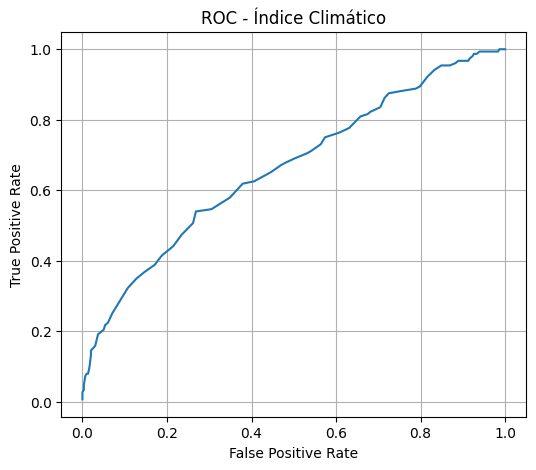

In [19]:
plt.figure(figsize=(6,5))
plt.plot(df_eval["FPR"], df_eval["TPR"])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC - Índice Climático")
plt.grid()
plt.show()

In [20]:
# Selección óptima del Trigger
df_eval["score"] = df_eval["FN_rate"] * 2 + df_eval["FP_rate"]

best = df_eval.loc[df_eval["score"].idxmin()]

trigger = best["threshold"]

print("Trigger óptimo:", trigger)

Trigger óptimo: -0.4193530694660015


In [21]:
# Validación
df_eval["youden"] = df_eval["TPR"] - df_eval["FPR"]
trigger = df_eval.loc[df_eval["youden"].idxmax(), "threshold"]

In [22]:
# Pérdida severa (límite inferior)
limite = df_model.loc[
    df_model["evento_perdida_global"] == 1,
    "indice_cluster"
].quantile(0.1)

print("Límite:", limite)

Límite: -1.4587754726186737


In [23]:
def payout(indice, trigger, limite):
    
    if indice >= trigger:
        return 0
    
    elif indice <= limite:
        return 1
    
    else:
        x = (trigger - indice) / (trigger - limite)
        return x**1.3                                 # Ajuste de prima por severidad (0 (muy laxo) 1.5 (Muy severo))

In [24]:
df_model["payout"] = df_model["indice_cluster"].apply(
    lambda x: payout(x, trigger, limite)
)

In [25]:
# Ajuste por clúster (Pago diferencial por región)
prima_cluster = df_model.groupby("cluster")["payout"].mean() 

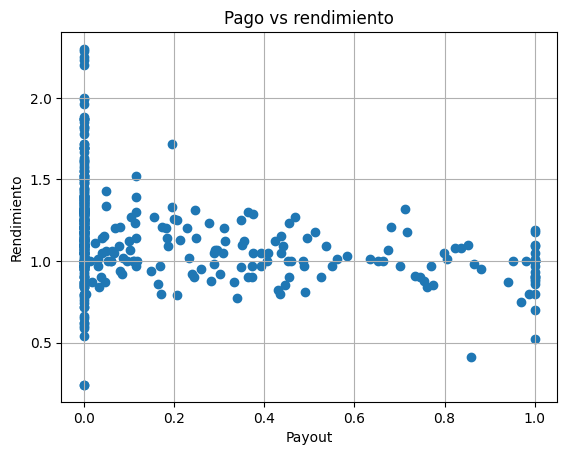

In [26]:
# Pago vs. Rendimiento
plt.scatter(df_model["payout"], df_model["Rendimiento (t/ha)"])
plt.xlabel("Payout")
plt.ylabel("Rendimiento")
plt.title("Pago vs rendimiento")
plt.grid()
plt.show()

In [27]:
# Pago promedio
df_model["payout"].mean()

0.155863508813795

In [28]:
# Pago en pérdida
df_model.loc[df_model["evento_perdida_global"] == 1, "payout"].mean()

0.27427182520766225

In [29]:
# Pago sin pérdida
df_model.loc[df_model["evento_perdida_global"] == 0, "payout"].mean()

0.09546732058605062

In [30]:
# Efectividad del seguro
efectividad = (
    df_model.loc[df_model["evento_perdida_global"] == 1, "payout"].mean()
    -
    df_model.loc[df_model["evento_perdida_global"] == 0, "payout"].mean()
)

print("Separación del seguro:", efectividad)

Separación del seguro: 0.17880450462161163


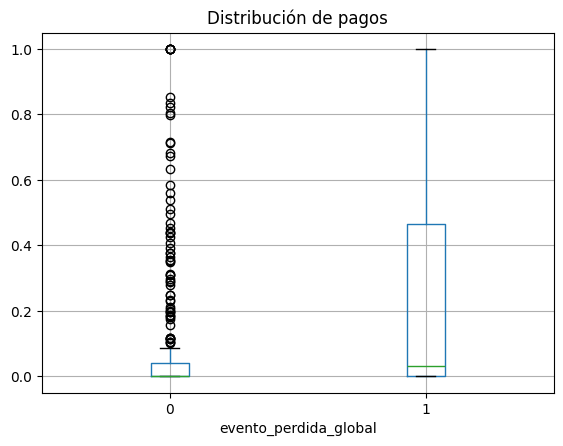

In [31]:
df_model.boxplot(column="payout", by="evento_perdida_global")
plt.title("Distribución de pagos")
plt.suptitle("")
plt.show()

In [32]:
prima = df_model["payout"].mean()
print("Prima pura:", prima)

margen = 0.30

prima_comercial = prima * (1 + margen)
print("Prima comercial:", prima_comercial)


Prima pura: 0.155863508813795
Prima comercial: 0.2026225614579335


### Simulación del riesgo

In [33]:
# Supuestos económicos
valor_asegurado = 1.0                             # 1 = 100% del valor asegurado
margen = 0.30                                     # margen comercial / gastos / utilidad
prima_pura = df_model["payout"].mean()
prima_comercial = prima_pura * (1 + margen)

print("Prima pura:", prima_pura)
print("Prima comercial:", prima_comercial)

Prima pura: 0.155863508813795
Prima comercial: 0.2026225614579335


In [34]:
# Ingreso por primas y egreso por pagos
df_model["prima_pura"] = prima_pura * valor_asegurado
df_model["prima_comercial"] = prima_comercial * valor_asegurado
df_model["indemnizacion"] = df_model["payout"] * valor_asegurado

df_model["resultado_puro"] = df_model["prima_pura"] - df_model["indemnizacion"]
df_model["resultado_comercial"] = df_model["prima_comercial"] - df_model["indemnizacion"]

df_model[[
    "municipio", "anio", "cluster", "Rendimiento (t/ha)",
    "indice_cluster", "riesgo", "payout",
    "prima_comercial", "indemnizacion", "resultado_comercial"
]].head(3)

,municipio,anio,cluster,Rendimiento (t/ha),indice_cluster,riesgo,payout,prima_comercial,indemnizacion,resultado_comercial
0,Aguadas,2007,1,0.97,0.528465,Bajo,0.0,0.202623,0.0,0.202623
1,Anserma,2007,2,1.30,-0.416760,Medio,0.0,0.202623,0.0,0.202623
2,Aranzazu,2007,1,1.01,-0.411458,Medio,0.0,0.202623,0.0,0.202623


In [35]:
# Resumen general del portafolio
resumen_portafolio = pd.DataFrame({
    "prima_pura_promedio": [df_model["prima_pura"].mean()],
    "prima_comercial_promedio": [df_model["prima_comercial"].mean()],
    "payout_promedio": [df_model["payout"].mean()],
    "indemnizacion_promedio": [df_model["indemnizacion"].mean()],
    "resultado_puro_promedio": [df_model["resultado_puro"].mean()],
    "resultado_comercial_promedio": [df_model["resultado_comercial"].mean()],
    "loss_ratio_puro": [df_model["indemnizacion"].sum() / df_model["prima_pura"].sum()],
    "loss_ratio_comercial": [df_model["indemnizacion"].sum() / df_model["prima_comercial"].sum()]
})

# resumen_portafolio

In [36]:
# Resultado anual del portafolio
resultado_anual = (
    df_model
    .groupby("anio")
    .agg(
        n=("anio", "size"),
        prima_total=("prima_comercial", "sum"),
        indemnizacion_total=("indemnizacion", "sum"),
        resultado_total=("resultado_comercial", "sum"),
        payout_promedio=("payout", "mean"),
        tasa_evento_perdida=("evento_perdida_global", "mean")
    )
    .reset_index()
)

resultado_anual["loss_ratio"] = (
    resultado_anual["indemnizacion_total"] /
    resultado_anual["prima_total"]
)

resultado_anual

,anio,n,prima_total,indemnizacion_total,resultado_total,payout_promedio,tasa_evento_perdida,loss_ratio
0,2007,25,5.065564,1.190070,3.875494,0.047603,0.28,0.234933
1,2008,25,5.065564,4.734477,0.331087,0.189379,0.40,0.934640
2,2009,25,5.065564,6.741056,-1.675492,0.269642,0.56,1.330761
3,2010,25,5.065564,1.063503,4.002061,0.042540,0.40,0.209948
4,2011,25,5.065564,3.707352,1.358212,0.148294,0.40,0.731874
5,2012,25,5.065564,7.007189,-1.941625,0.280288,0.88,1.383299
6,2013,25,5.065564,4.106772,0.958792,0.164271,0.76,0.810724
7,2014,25,5.065564,5.900151,-0.834587,0.236006,0.16,1.164757
8,2015,25,5.065564,8.049209,-2.983645,0.321968,0.08,1.589006
9,2016,25,5.065564,1.227187,3.838377,0.049087,0.08,0.242261


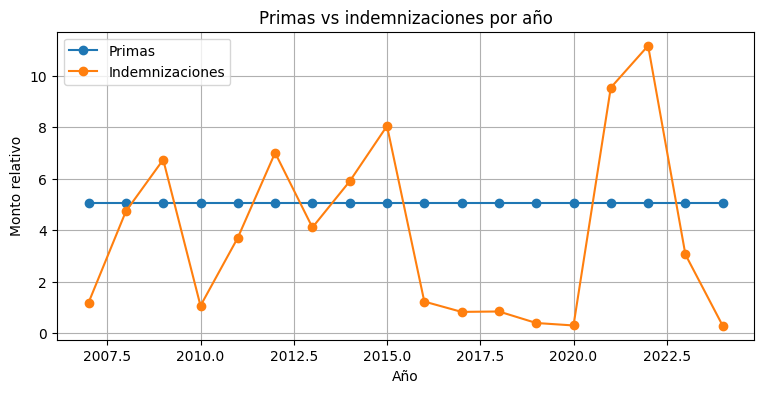

In [37]:
# Visualización del resultado anual
plt.figure(figsize=(9, 4))
plt.plot(resultado_anual["anio"], resultado_anual["prima_total"], marker="o", label="Primas")
plt.plot(resultado_anual["anio"], resultado_anual["indemnizacion_total"], marker="o", label="Indemnizaciones")
plt.xlabel("Año")
plt.ylabel("Monto relativo")
plt.title("Primas vs indemnizaciones por año")
plt.legend()
plt.grid()
plt.show()

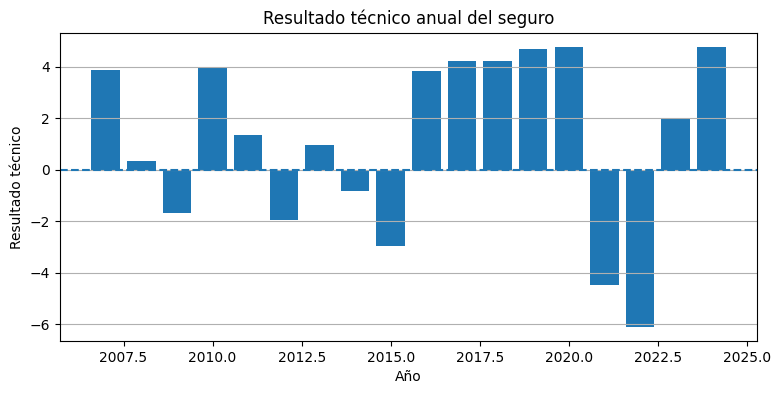

In [38]:
plt.figure(figsize=(9, 4))
plt.bar(resultado_anual["anio"], resultado_anual["resultado_total"])
plt.axhline(0, linestyle="--")
plt.xlabel("Año")
plt.ylabel("Resultado técnico")
plt.title("Resultado técnico anual del seguro")
plt.grid(axis="y")
plt.show()

In [39]:
# Evaluación por clúster
resultado_cluster = (
    df_model
    .groupby("cluster")
    .agg(
        n=("cluster", "size"),
        prima_total=("prima_comercial", "sum"),
        indemnizacion_total=("indemnizacion", "sum"),
        resultado_total=("resultado_comercial", "sum"),
        payout_promedio=("payout", "mean"),
        tasa_evento_perdida=("evento_perdida_global", "mean")
    )
    .reset_index()
)

resultado_cluster["loss_ratio"] = (
    resultado_cluster["indemnizacion_total"] /
    resultado_cluster["prima_total"]
)

resultado_cluster

,cluster,n,prima_total,indemnizacion_total,resultado_total,payout_promedio,tasa_evento_perdida,loss_ratio
0,0,36,7.294412,5.637369,1.657044,0.156594,0.500000,0.772834
1,1,162,32.824855,24.814601,8.010254,0.153177,0.345679,0.755970
2,2,198,40.119267,29.810736,10.308532,0.150559,0.262626,0.743053
3,3,54,10.941618,9.875874,1.065744,0.182887,0.481481,0.902597


In [40]:
# Evaluación por nivel de riesgo
resultado_riesgo = (
    df_model
    .groupby("riesgo")
    .agg(
        n=("riesgo", "size"),
        prima_total=("prima_comercial", "sum"),
        indemnizacion_total=("indemnizacion", "sum"),
        resultado_total=("resultado_comercial", "sum"),
        payout_promedio=("payout", "mean"),
        tasa_evento_perdida=("evento_perdida_global", "mean"),
        rendimiento_promedio=("Rendimiento (t/ha)", "mean")
    )
    .reset_index()
)

resultado_riesgo["loss_ratio"] = (
    resultado_riesgo["indemnizacion_total"] /
    resultado_riesgo["prima_total"]
)

resultado_riesgo

,riesgo,n,prima_total,indemnizacion_total,resultado_total,payout_promedio,tasa_evento_perdida,rendimiento_promedio,loss_ratio
0,Alto,135,27.354046,69.086749,-41.732703,0.511754,0.511111,1.030593,2.525650
1,Bajo,135,27.354046,0.000000,27.354046,0.000000,0.222222,1.246370,0.000000
2,Medio,180,36.472061,1.051830,35.420231,0.005844,0.294444,1.172944,0.028839


In [41]:
# Simulación Monte Carlo simple por remuestreo histórico
n_sim = 5000
n_polizas = 100

simulaciones = []

for i in range(n_sim):
    muestra = df_model.sample(n=n_polizas, replace=True, random_state=i)
    
    prima_total = muestra["prima_comercial"].sum()
    indemnizacion_total = muestra["indemnizacion"].sum()
    resultado_total = prima_total - indemnizacion_total
    loss_ratio = indemnizacion_total / prima_total
    
    simulaciones.append({
        "sim": i,
        "prima_total": prima_total,
        "indemnizacion_total": indemnizacion_total,
        "resultado_total": resultado_total,
        "loss_ratio": loss_ratio
    })

df_sim = pd.DataFrame(simulaciones)

df_sim.describe()

,sim,prima_total,indemnizacion_total,resultado_total,loss_ratio
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2499.500000,20.262256,15.629639,4.632618,0.771367
std,1443.520003,0.000000,2.929464,2.929464,0.144577
min,0.000000,20.262256,5.382788,-6.658831,0.265656
25%,1249.750000,20.262256,13.568167,2.663765,0.669628
50%,2499.500000,20.262256,15.514932,4.747324,0.765706
75%,3749.250000,20.262256,17.598491,6.694089,0.868536
max,4999.000000,20.262256,26.921087,14.879468,1.328632


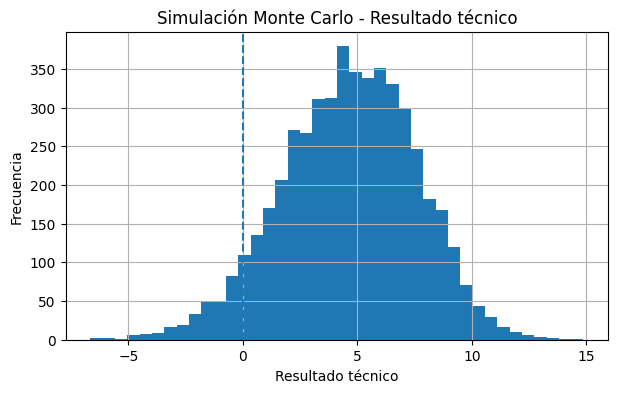

In [42]:
# Distribución del resultado técnico simulado
plt.figure(figsize=(7, 4))
plt.hist(df_sim["resultado_total"], bins=40)
plt.axvline(0, linestyle="--")
plt.xlabel("Resultado técnico")
plt.ylabel("Frecuencia")
plt.title("Simulación Monte Carlo - Resultado técnico")
plt.grid()
plt.show()

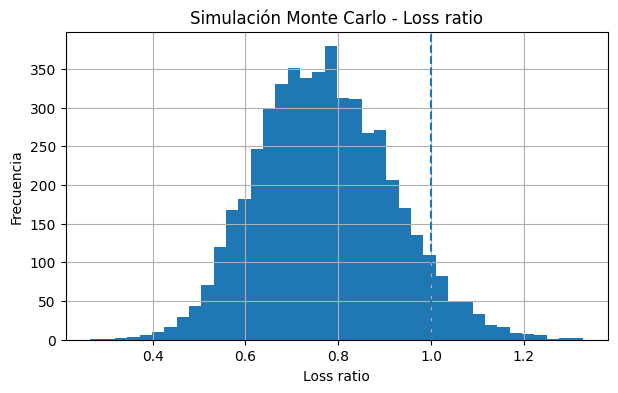

In [43]:
# Distribución del loss ratio simulado
plt.figure(figsize=(7, 4))
plt.hist(df_sim["loss_ratio"], bins=40)
plt.axvline(1, linestyle="--")
plt.xlabel("Loss ratio")
plt.ylabel("Frecuencia")
plt.title("Simulación Monte Carlo - Loss ratio")
plt.grid()
plt.show()

In [44]:
# Métricas de riesgo financiero
prob_perdida_aseguradora = (df_sim["resultado_total"] < 0).mean()
loss_ratio_promedio = df_sim["loss_ratio"].mean()
loss_ratio_p95 = df_sim["loss_ratio"].quantile(0.95)
resultado_p05 = df_sim["resultado_total"].quantile(0.05)

print("Probabilidad de pérdida para aseguradora:", prob_perdida_aseguradora)
print("Loss ratio promedio:", loss_ratio_promedio)
print("Loss ratio P95:", loss_ratio_p95)
print("Resultado técnico P05:", resultado_p05)

Probabilidad de pérdida para aseguradora: 0.0618
Loss ratio promedio: 0.7713671377536071
Loss ratio P95: 1.0180525689416011
Resultado técnico P05: -0.36578577598431555


In [45]:
# Guardar salidas de simulación
# resultado_anual.to_csv(path / "resultado_anual_seguro.csv", index=False)
# resultado_cluster.to_csv(path / "resultado_cluster_seguro.csv", index=False)
# resultado_riesgo.to_csv(path / "resultado_riesgo_seguro.csv", index=False)
# df_sim.to_csv(path / "simulacion_montecarlo_seguro.csv", index=False)

print("Archivos de simulación guardados correctamente")

Archivos de simulación guardados correctamente
